In [1]:
import pandas as pd
import numpy as np

In [ ]:
internal_df = pd.read_excel("../data/datasets/Internal_Bank_Dataset_augmented.xlsx")
external_df = pd.read_excel("../data/datasets/External_Cibil_Dataset_augmented.xlsx")
unseen_df = pd.read_excel("../data/datasets/Unseen_Dataset.xlsx", sheet_name="Sheet1")

ValueError: Worksheet named 'case_study1' not found

In [ ]:
#Merge the dataset internal + external
df = pd.merge(internal_df, external_df, on="PROSPECTID", how="inner")
print(df.shape)

(51336, 87)


In [ ]:
#Clean missing values
# -99999 means "missing" in this dataset
df = df.replace(-99999, np.nan)

# these columns are too incomplete to keep (45%+ missing)
df = df.drop(columns=[
    "CC_utilization", "PL_utilization", "max_delinquency_level",
    "time_since_recent_deliquency", "time_since_first_deliquency",
    "max_unsec_exposure_inPct"
])

# fill remaining gaps with the median (keeps all rows)
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(df.isna().sum().sum())   # should be 0

0


In [ ]:
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,0.0,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,0.0,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.0,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,0.0,0,0,AL,AL,753,P1


In [ ]:
df.dtypes

PROSPECTID             int64
Total_TL               int64
Tot_Closed_TL          int64
Tot_Active_TL          int64
Total_TL_opened_L6M    int64
                       ...  
GL_Flag                int64
last_prod_enq2           str
first_prod_enq2          str
Credit_Score           int64
Approved_Flag            str
Length: 81, dtype: object

In [ ]:
print(df.shape)
print(df.columns.tolist())

(51336, 81)
['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'en

In [ ]:
df.isnull().sum()

PROSPECTID             0
Total_TL               0
Tot_Closed_TL          0
Tot_Active_TL          0
Total_TL_opened_L6M    0
                      ..
GL_Flag                0
last_prod_enq2         0
first_prod_enq2        0
Credit_Score           0
Approved_Flag          0
Length: 81, dtype: int64

In [ ]:
df.describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,0.835846,0.089469,0.167874,0.190414,0.065182,0.170492,0.056302,0.271116,0.052887,679.859222
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,36.802321,0.285423,0.373758,0.376218,0.235706,0.350209,0.213506,0.444540,0.223810,20.502764
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,469.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,0.089000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,669.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,0.618000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,680.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,0.888000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,691.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,6327.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,811.000000


In [ ]:
#Encode text columns to numbers
df["GENDER"] = df["GENDER"].map({"M": 1, "F": 0})
df["MARITALSTATUS"] = df["MARITALSTATUS"].map({"Married": 1, "Single": 0})

df["EDUCATION"] = df["EDUCATION"].map({
    "OTHERS": 1, "SSC": 2, "12TH": 3,
    "UNDER GRADUATE": 4, "GRADUATE": 4,
    "POST-GRADUATE": 5, "PROFESSIONAL": 5
})

df["Approved_Flag"] = df["Approved_Flag"].map({"P1": 0, "P2": 1, "P3": 2, "P4": 3})

df = pd.get_dummies(df, columns=["last_prod_enq2", "first_prod_enq2"], dtype=int)

In [ ]:
#target variable overview
df["Approved_Flag"].value_counts()

Approved_Flag
1    32199
2     7452
3     5882
0     5803
Name: count, dtype: int64

In [ ]:
# remove the leftover EDA-only column if it exists
if "Approved_Flag_encoded" in df.columns:
    df = df.drop(columns=["Approved_Flag_encoded"])

X = df.drop(columns=["PROSPECTID", "Approved_Flag", "Credit_Score"])
y = df["Approved_Flag"]

print("Missing values in X:", X.isna().sum().sum())

Missing values in X: 0


In [ ]:
print(df.isna().sum()[df.isna().sum() > 0])

Series([], dtype: int64)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# check which columns have -99999, and how many
sentinel_check = (df.select_dtypes(include=np.number) == -99999).sum()
sentinel_check = sentinel_check[sentinel_check > 0].sort_values(ascending=False)
print(sentinel_check)

Series([], dtype: int64)


In [ ]:
print(df.shape)

(51336, 91)


In [ ]:
df.describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_AL,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,0.346599,0.017590,0.155037,0.405778,0.055906,0.042621,0.231027,0.027447,0.095235,0.547764
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,0.475891,0.131457,0.361944,0.491047,0.229743,0.202003,0.421494,0.163382,0.293543,0.497718
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#outliers
df["pct_currentBal_all_TL"].sort_values(ascending=False).head(10)

41860    6327.500
22427    5000.000
45911    1593.792
3133     1348.000
13773     338.347
23389     139.286
23673      76.638
51087      70.675
10478      23.154
31129      21.000
Name: pct_currentBal_all_TL, dtype: float64

In [ ]:
#actual affected rows- outliers
(df["pct_currentBal_all_TL"] > 1).sum()

np.int64(4341)

In [ ]:
print("\nPercentage:\n", df["Approved_Flag"].value_counts(normalize=True) * 100)


Percentage:
 Approved_Flag
1    62.722066
2    14.516129
3    11.457846
0    11.303958
Name: proportion, dtype: float64


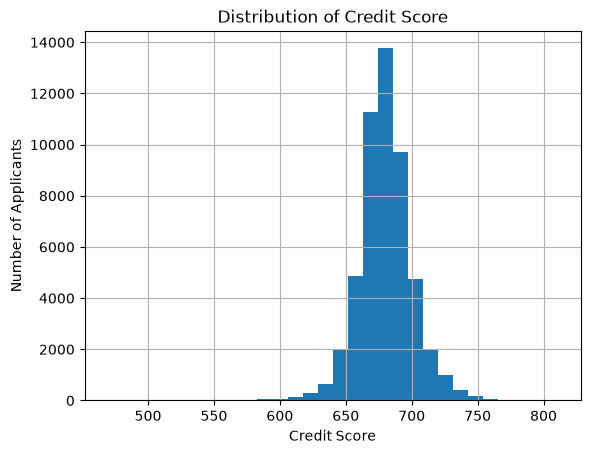

In [ ]:
#univariate analysis
import matplotlib.pyplot as plt
df["Credit_Score"].hist(bins=30)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.show()

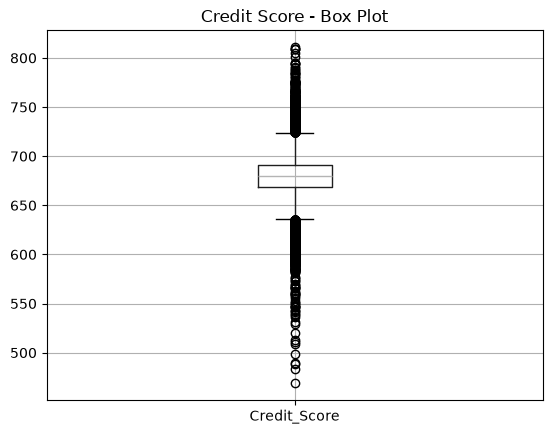

In [ ]:
#Box plot for outliers
df.boxplot(column="Credit_Score")
plt.title("Credit Score - Box Plot")
plt.show()

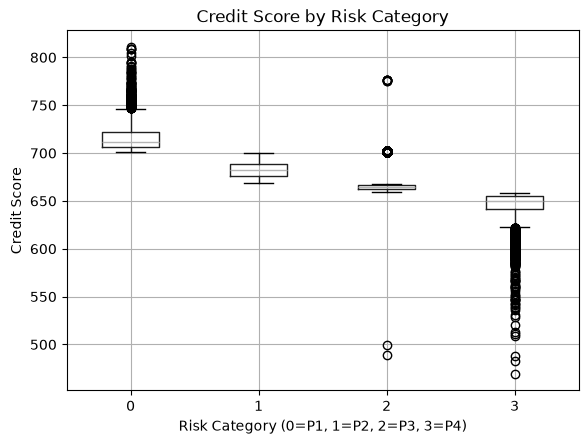

In [ ]:
#Bivariate analysis — Credit Score vs Risk Category
df.boxplot(column="Credit_Score", by="Approved_Flag")
plt.title("Credit Score by Risk Category")
plt.suptitle("")  # removes an auto-generated subtitle pandas adds
plt.xlabel("Risk Category (0=P1, 1=P2, 2=P3, 3=P4)")
plt.ylabel("Credit Score")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

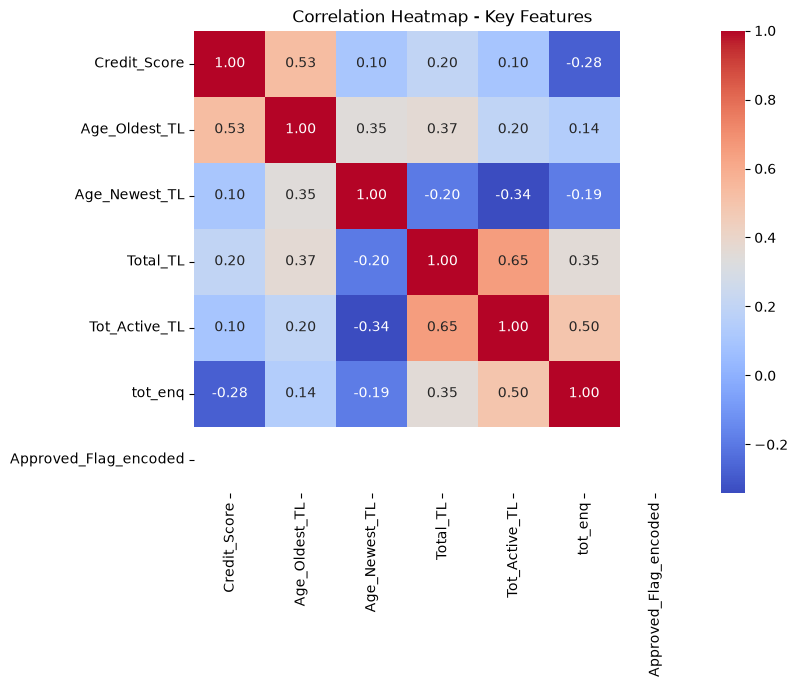

In [ ]:
#Multivariate analysis — Correlation heatmap
# encode the target column to numbers first (needed for correlation)
import seaborn as sns
import matplotlib.pyplot as plt

df["Approved_Flag_encoded"] = df["Approved_Flag"].map({"P1": 0, "P2": 1, "P3": 2, "P4": 3})

# pick a handful of important columns to keep the heatmap readable
cols_to_check = ["Credit_Score", "Age_Oldest_TL", "Age_Newest_TL", "Total_TL",
                  "Tot_Active_TL", "tot_enq", "Approved_Flag_encoded"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Key Features")
plt.show

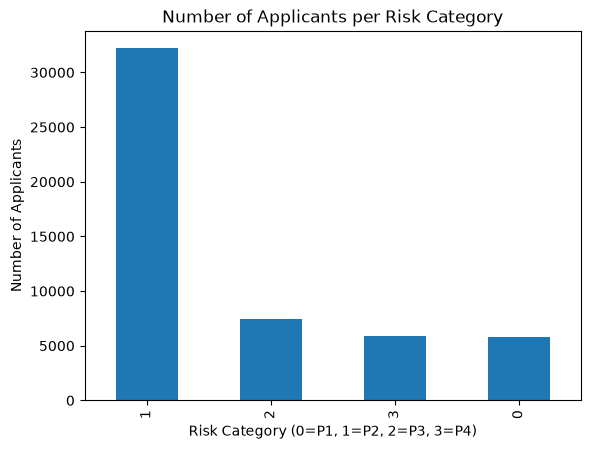

In [ ]:
#univariate analysis: Target Variable Distribution
import matplotlib.pyplot as plt

df["Approved_Flag"].value_counts().plot(kind="bar")
plt.title("Number of Applicants per Risk Category")
plt.xlabel("Risk Category (0=P1, 1=P2, 2=P3, 3=P4)")
plt.ylabel("Number of Applicants")
plt.show()

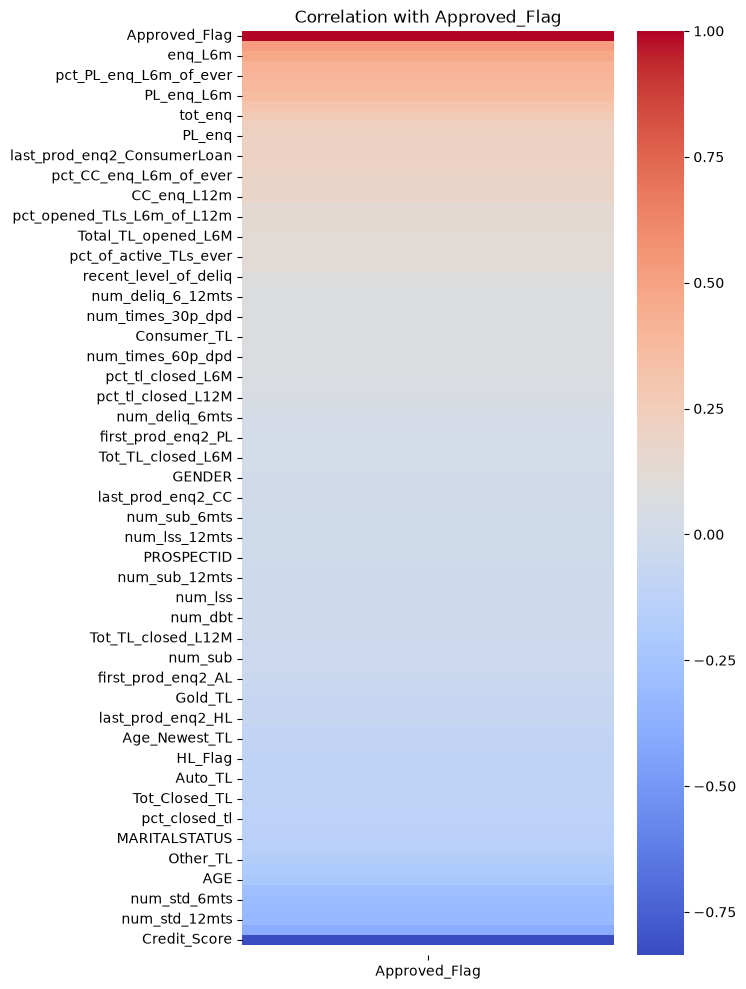

In [ ]:
#Multivariate Analysis: Correlation with Target Variable
import seaborn as sns

plt.figure(figsize=(6, 12))
corr = df.corr()["Approved_Flag"].sort_values(ascending=False)
sns.heatmap(corr.to_frame(), annot=False, cmap="coolwarm")
plt.title("Correlation with Approved_Flag")
plt.show()

In [ ]:
#Set X (features) and y (target)
# drop ID (not useful) and Credit_Score (causes leakage - it was used to create the target)
X = df.drop(columns=["PROSPECTID", "Approved_Flag", "Credit_Score"])
y = df["Approved_Flag"]

In [ ]:
#Split into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/home/yadu/Documents/AI_ML/python_notebooks/bank_analytics/banking_analytics/lib/python3.14/site-packages/sklearn/utils/extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/yadu/Documents/AI_ML/python_notebooks/bank_analytics/banking_analytics/lib/python3.14/site-packages/sklearn/utils/extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/yadu/Documents/AI_ML/python_notebooks/bank_analytics/banking_analytics/lib/python3.14/site-packages/sklearn/utils/extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
#Train a model and check accuracy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["P1", "P2", "P3", "P4"]))

Accuracy: 0.7488313206077133
              precision    recall  f1-score   support

          P1       0.67      0.89      0.76      1161
          P2       0.90      0.79      0.84      6440
          P3       0.40      0.48      0.43      1491
          P4       0.68      0.74      0.71      1176

    accuracy                           0.75     10268
   macro avg       0.66      0.72      0.69     10268
weighted avg       0.77      0.75      0.76     10268



In [ ]:
# import xgboost as xgb
# from sklearn.model_selection import GridSearchCV
# from sklearn.utils.class_weight import compute_sample_weight

# # 1. Translate hyperparameters to XGBoost equivalents
# param_grid_rf = {
#     "n_estimators": [100, 200],
#     "max_depth": [10, 20, 0],   # '0' is XGBoost's version of 'None' (unlimited depth)
#     "min_child_weight": [1, 2]  # XGBoost's closest equivalent to min_samples_leaf
# }

# grid_search_rf = GridSearchCV(
#     # Swap out RandomForestClassifier for XGBoost's RF implementation
#     xgb.XGBRFClassifier(
#         tree_method="hist", 
#         device="cuda", 
#         random_state=42
#     ),
#     param_grid_rf,
#     cv=3,
#     scoring="accuracy",
#     n_jobs=2  # Prevent GPU Out-of-Memory crashes
# )

# # 2. Replicate class_weight="balanced" behavior
# sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# # 3. Fit the model and pass the weights in
# grid_search_rf.fit(
#     X_train_scaled, 
#     y_train, 
#     sample_weight=sample_weights 
# )

# print("Best settings found for XGBoost RF:", grid_search_rf.best_params_)
# print("Best cross-validation accuracy for XGBoost RF:", grid_search_rf.best_score_)

/home/yadu/Documents/AI_ML/python_notebooks/bank_analytics/banking_analytics/lib/python3.14/site-packages/xgboost/core.py:569: FutureWarning: `XGBRFClassifier` is deprecated and will be removed in a future release. The estimator is a thin wrapper over the boosting interface and does not implement a conventional random forest; features like early stopping are unsupported. Set `num_parallel_tree` along with `n_estimators=1` on the corresponding boosting estimator instead, or use a dedicated random forest implementation like those in `sklearn.ensemble`.
  return func(**kwargs)
/home/yadu/Documents/AI_ML/python_notebooks/bank_analytics/banking_analytics/lib/python3.14/site-packages/xgboost/core.py:569: FutureWarning: `XGBRFClassifier` is deprecated and will be removed in a future release. The estimator is a thin wrapper over the boosting interface and does not implement a conventional random forest; features like early stopping are unsupported. Set `num_parallel_tree` along with `n_estimat

KeyboardInterrupt: 

In [ ]:
# best_rf_model = grid_search_rf.best_estimator_
# y_pred_tuned_rf = best_rf_model.predict(X_test_scaled)

# print("Accuracy for Tuned RandomForestClassifier:", accuracy_score(y_test, y_pred_tuned_rf))
# print(classification_report(y_test, y_pred_tuned_rf, target_names=["P1", "P2", "P3", "P4"]))

ValueError: Feature shape mismatch, expected: 89, got 88

In [ ]:
# Diagnostic: find out where the NaN is coming from
print("NaNs in df:", df.isna().sum().sum())
print("NaNs in X:", X.isna().sum().sum())
print("NaNs in X_train:", X_train.isna().sum().sum())

# Fix: re-create everything fresh from df, in the correct order
if "Approved_Flag_encoded" in df.columns:
    df = df.drop(columns=["Approved_Flag_encoded"])

X = df.drop(columns=["PROSPECTID", "Approved_Flag", "Credit_Score"])
y = df["Approved_Flag"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nAfter fix - NaNs in X_train_scaled:", pd.DataFrame(X_train_scaled).isna().sum().sum())

NaNs in df: 51336
NaNs in X: 51336
NaNs in X_train: 41068

After fix - NaNs in X_train_scaled: 0


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model2 = GradientBoostingClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2, target_names=["P1", "P2", "P3", "P4"]))

Accuracy: 0.7902220490845345
              precision    recall  f1-score   support

          P1       0.82      0.76      0.79      1161
          P2       0.82      0.94      0.88      6440
          P3       0.47      0.23      0.31      1491
          P4       0.78      0.71      0.74      1176

    accuracy                           0.79     10268
   macro avg       0.72      0.66      0.68     10268
weighted avg       0.76      0.79      0.77     10268



In [ ]:
from sklearn.linear_model import LogisticRegression

model3 = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model3.fit(X_train_scaled, y_train)

y_pred3 = model3.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3, target_names=["P1", "P2", "P3", "P4"]))

Accuracy: 0.6918582002337359
              precision    recall  f1-score   support

          P1       0.63      0.91      0.74      1161
          P2       0.89      0.69      0.78      6440
          P3       0.33      0.50      0.40      1491
          P4       0.64      0.72      0.68      1176

    accuracy                           0.69     10268
   macro avg       0.62      0.70      0.65     10268
weighted avg       0.75      0.69      0.71     10268



In [ ]:
from sklearn.tree import DecisionTreeClassifier

model4 = DecisionTreeClassifier(class_weight="balanced", random_state=42)
model4.fit(X_train_scaled, y_train)

y_pred4 = model4.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred4))
print(classification_report(y_test, y_pred4, target_names=["P1", "P2", "P3", "P4"]))

Accuracy: 0.721172574990261
              precision    recall  f1-score   support

          P1       0.69      0.69      0.69      1161
          P2       0.83      0.83      0.83      6440
          P3       0.34      0.34      0.34      1491
          P4       0.67      0.66      0.66      1176

    accuracy                           0.72     10268
   macro avg       0.63      0.63      0.63     10268
weighted avg       0.72      0.72      0.72     10268



In [ ]:
#save

pd.DataFrame(X_train_scaled, columns=X.columns).to_csv("../data/processed/X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled, columns=X.columns).to_csv("../data/processed/X_test_scaled.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

# from google.colab import files
# files.download("X_train_scaled.csv")
# files.download("X_test_scaled.csv")
# files.download("y_train.csv")
# files.download("y_test.csv")

In [ ]:
# same cleaning as before
unseen_df = unseen_df.replace(-99999, np.nan)

# drop the same 6 columns (if present)
drop_cols = ["CC_utilization", "PL_utilization", "max_delinquency_level",
             "time_since_recent_deliquency", "time_since_first_deliquency",
             "max_unsec_exposure_inPct"]
unseen_df = unseen_df.drop(columns=[c for c in drop_cols if c in unseen_df.columns])

# encode the same categorical columns
unseen_df["GENDER"] = unseen_df["GENDER"].map({"M": 1, "F": 0})
unseen_df["MARITALSTATUS"] = unseen_df["MARITALSTATUS"].map({"Married": 1, "Single": 0})
unseen_df["EDUCATION"] = unseen_df["EDUCATION"].map({
    "OTHERS": 1, "SSC": 2, "12TH": 3,
    "UNDER GRADUATE": 4, "GRADUATE": 4,
    "POST-GRADUATE": 5, "PROFESSIONAL": 5
})
unseen_df = pd.get_dummies(unseen_df, columns=["last_prod_enq2", "first_prod_enq2"], dtype=int)

# fill any missing values using TRAINING medians (not unseen's own)
for col in X.columns:
    if col in unseen_df.columns:
        unseen_df[col] = unseen_df[col].fillna(X[col].median())
    else:
        unseen_df[col] = 0   # column didn't appear in this small unseen set

# match column order exactly to X
unseen_df = unseen_df[X.columns]

print(unseen_df.shape)   # should be (100, same number of columns as X)

(100, 88)


In [ ]:
#Predict using Gradient Boosting
unseen_scaled = scaler.transform(unseen_df)

predictions = model2.predict(unseen_scaled)

# convert back to readable labels
label_map = {0: "P1", 1: "P2", 2: "P3", 3: "P4"}
predicted_labels = [label_map[p] for p in predictions]

print(pd.Series(predicted_labels).value_counts())

P2    79
P4    10
P1     6
P3     5
Name: count, dtype: int64


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

xgb_model = xgb.XGBClassifier(
        tree_method="hist", 
        device="cuda",
        random_state=42
    )

grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best settings found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

/home/yadu/Documents/AI_ML/python_notebooks/bank_analytics/banking_analytics/lib/python3.14/site-packages/xgboost/core.py:569: UserWarning: [18:00:42] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best settings found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best cross-validation accuracy: 0.7950959808894668


In [ ]:
import joblib
import json

best_xgb_model = grid_search.best_estimator_

# 2. Save the tuned model directly to your VS Code directory
joblib.dump(best_xgb_model, '../models/xgboost_model.pkl')
print("Model saved successfully: /models/xgboost_model.pkl")

# 3. Save the exact scaler you used
# NOTE: Replace 'scaler' with whatever variable name you used for your StandardScaler
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved successfully: /models/scaler.pkl")

# 4. Save the feature order
# NOTE: If X_train_scaled is a NumPy array (which happens after scaling), 
# use your original unscaled 'X_train' DataFrame here to grab the column names.
feature_columns = list(X_train.columns)

with open('../models/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print("Feature columns saved successfully: feature_columns.json")

Model saved successfully: xgboost_model.pkl
Scaler saved successfully: scaler.pkl
Feature columns saved successfully: feature_columns.json


In [ ]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, target_names=["P1", "P2", "P3", "P4"]))

Accuracy: 0.7969419555901831
              precision    recall  f1-score   support

          P1       0.81      0.79      0.80      1161
          P2       0.84      0.93      0.88      6440
          P3       0.48      0.28      0.35      1491
          P4       0.76      0.74      0.75      1176

    accuracy                           0.80     10268
   macro avg       0.72      0.68      0.70     10268
weighted avg       0.77      0.80      0.78     10268

